In [1]:
from rdkit import Chem
from rdkit.Chem import Draw
# --- Saving helpers ---
from PIL import Image


In [12]:
inp = "CC(C)(C)OC(=O)N1CCC(S(N)(=O)=O)CC1.COc1ccc(B(O)O)cc1>CC(=O)[O-].CC(=O)[O-].[Cu+2].CCN(CC)CC.CO"
out = "COc1ccc(NS(=O)(=O)C2CCN(C(=O)OC(C)(C)C)CC2)cc1"

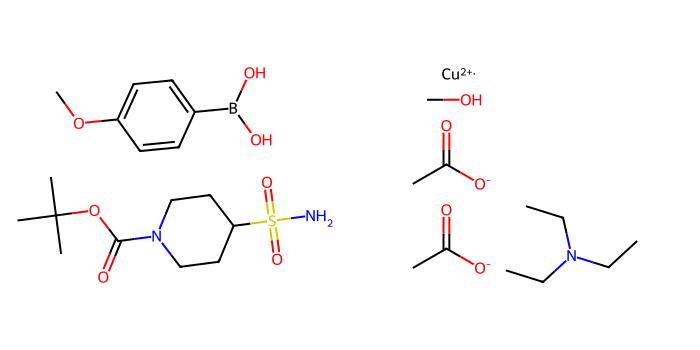

In [13]:
mol_inps = inp.split(">")
mols = [Chem.MolFromSmiles(s) for s in mol_inps]

# Filter out invalid SMILES and warn
valid_mols = []
invalid_indices = []
for i, m in enumerate(mols):
    if m is None:
        invalid_indices.append(i)
    else:
        valid_mols.append(m)

if invalid_indices:
    print(f"Warning: {len(invalid_indices)} invalid SMILES at indices: {invalid_indices}")

mols = valid_mols

# Create grid image (PIL Image) if there are valid molecules
if mols:
    try:
        img = Draw.MolsToGridImage(
            mols,
            molsPerRow=2,
            subImgSize=(350, 350),
        )
    except Exception as e:
        print("Failed to create grid image:", e)
        img = None
else:
    print("No valid molecules to draw.")
    img = None

# Display in notebook (existing behavior)
img


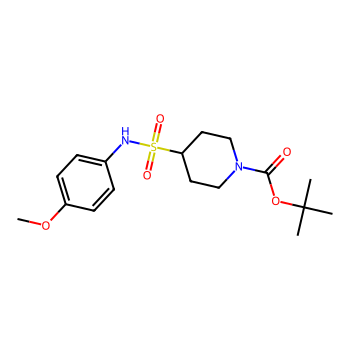

In [14]:
mol_out = Chem.MolFromSmiles(out)
# Create grid image (PIL Image)
img2 = Draw.MolToImage(mol_out, size=(350, 350))

# Display in notebook (existing behavior)
img2

In [ ]:
# --- Saving helpers (PNG-only, auto-detect input type) ---
from PIL import Image
from rdkit.Chem.rdchem import Mol as RDMol
from rdkit.Chem import Draw


def save_png_auto(obj, fname="image.png", molsPerRow=4, subImgSize=(300,300)):
    """Save `obj` as a PNG file.

    Supported `obj` types:
    - PIL.Image.Image -> saved directly
    - rdkit.Chem.rdchem.Mol -> single mol rendered with `Draw.MolToImage`
    - list/tuple of rdkit Mols -> rendered with `Draw.MolsToGridImage` (but prefer batching for large lists)
    - IPython.display.Image-like -> write `.data` bytes
    - Any object with a `.save(path)` method -> call it
    """
    if obj is None:
        print(f"save_png_auto: nothing to save for {fname}")
        return False

    # 1) PIL Image
    try:
        from PIL.Image import Image as PILImage
        if isinstance(obj, PILImage):
            try:
                obj.save(fname, format="PNG")
                print(f"Saved PNG: {fname}")
                return True
            except Exception as e:
                print(f"Failed to save PNG {fname}: {e}")
                return False
    except Exception:
        pass

    # 2) single RDKit Mol -> render then save
    if isinstance(obj, RDMol):
        try:
            pil_img = Draw.MolToImage(obj, size=subImgSize)
            pil_img.save(fname, format="PNG")
            print(f"Saved PNG from Mol: {fname}")
            return True
        except Exception as e:
            print(f"Failed to save Mol PNG {fname}: {e}")
            return False

    # 3) list/tuple of mols -> grid (small lists only)
    if isinstance(obj, (list, tuple)):
        mols_valid = [m for m in obj if m is not None]
        if not mols_valid:
            print(f"save_png_auto: no valid molecules to draw, nothing saved to {fname}")
            return False
        if len(mols_valid) > 50:
            print(f"save_png_auto: list too large ({len(mols_valid)}), use batching via save_each_mol_batched()")
            return False
        try:
            pil_img = Draw.MolsToGridImage(mols_valid, molsPerRow=molsPerRow, subImgSize=subImgSize)
            try:
                pil_img.save(fname, format="PNG")
                print(f"Saved grid PNG: {fname}")
                return True
            except Exception:
                pass
        except Exception as e:
            print(f"Failed to create grid image: {e}")

    # 4) generic: object has .save(path)
    save_method = getattr(obj, "save", None)
    if callable(save_method):
        try:
            save_method(fname)
            print(f"Saved via object's .save(): {fname}")
            return True
        except Exception as e:
            print(f"Failed using object's save() for {fname}: {e}")
            return False

    # 5) IPython/rdkit image-like with .data bytes
    data = getattr(obj, "data", None)
    if isinstance(data, (bytes, bytearray)):
        try:
            with open(fname, "wb") as fh:
                fh.write(data)
            print(f"Saved binary image data to: {fname}")
            return True
        except Exception as e:
            print(f"Failed to write binary image data to {fname}: {e}")
            return False

    print(f"save_png_auto: unsupported object type {type(obj)} for {fname}")
    return False


def save_each_mol(mols, prefix="mol", subImgSize=(300,300)):
    """Save each RDKit Mol in `mols` to its own PNG file.

    Returns a list of successfully written filenames.
    """
    if not mols:
        print(f"save_each_mol: empty list, nothing saved")
        return []
    mols_valid = [m for m in mols if m is not None]
    if not mols_valid:
        print(f"save_each_mol: no valid molecules to save")
        return []

    saved_files = []
    for i, m in enumerate(mols_valid, start=1):
        fname = f"{prefix}_{i}.png"
        try:
            pil_img = Draw.MolToImage(m, size=subImgSize)
            pil_img.save(fname, format="PNG")
            saved_files.append(fname)
            print(f"Saved: {fname}")
        except Exception as e:
            print(f"Failed to save {fname}: {e}")
    return saved_files

In [16]:
save_png_auto(img, "reactants.png")
save_png_auto(img2, "product.png")
# Save each reactant in `mols` to its own file using batching to limit memory
saved = save_each_mol_batched(mols, prefix="reactant", subImgSize=(350,350), batch_size=1, grid_per_batch=False)
print("Saved files:", saved)


Saved PNG: product.png
Saved: reactant_1.png
Saved: reactant_2.png


['reactant_1.png', 'reactant_2.png']